In [21]:
import torch
import matplotlib.pyplot as plt
from graphs import plot_loss_flattening
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

In [22]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [23]:
from models.resnet import run

path = "./normalized_images"

num_epochs = 5
lr = 1e-4
threshold = 0.6

model, train_losses, eval_losses, eval_preds, eval_labels, test_preds, test_labels = run(path, device, num_epochs=num_epochs, lr=lr, test=True, threshold=threshold)

-- ResNet18 | Epochs: 5 | LR: 0.0001
Epoch 1/5 - Train Loss: 0.2580, Eval Loss: 0.2262
Epoch 2/5 - Train Loss: 0.2132, Eval Loss: 0.2188
Epoch 3/5 - Train Loss: 0.2092, Eval Loss: 0.2215
Epoch 4/5 - Train Loss: 0.2015, Eval Loss: 0.2130
Epoch 5/5 - Train Loss: 0.2037, Eval Loss: 0.2150
Training time: 344.517s
Train:
               precision    recall  f1-score   support

      NORMAL       1.00      0.83      0.91      7263
   PNEUMONIA       0.69      0.99      0.82      2737

    accuracy                           0.88     10000
   macro avg       0.85      0.91      0.86     10000
weighted avg       0.91      0.88      0.88     10000

Eval:
               precision    recall  f1-score   support

      NORMAL       1.00      0.81      0.89       900
   PNEUMONIA       0.77      1.00      0.87       570

    accuracy                           0.88      1470
   macro avg       0.88      0.90      0.88      1470
weighted avg       0.91      0.88      0.88      1470

Test:
              

In [24]:
from sklearn.metrics import classification_report                                                  
for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:                                                                        
    print(f"\nThreshold: {threshold}")                                                                               
    print(classification_report(                                                                                     
        test_labels.astype(int),                                                                                     
        (test_preds >= threshold).astype(int),                                                                       
        target_names=["NORMAL", "PNEUMONIA"]                                                                         
    ))  


Threshold: 0.5
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.87       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91      0.89      0.89      1505


Threshold: 0.55
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.87       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91      0.89      0.89      1505


Threshold: 0.6
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.88       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91  

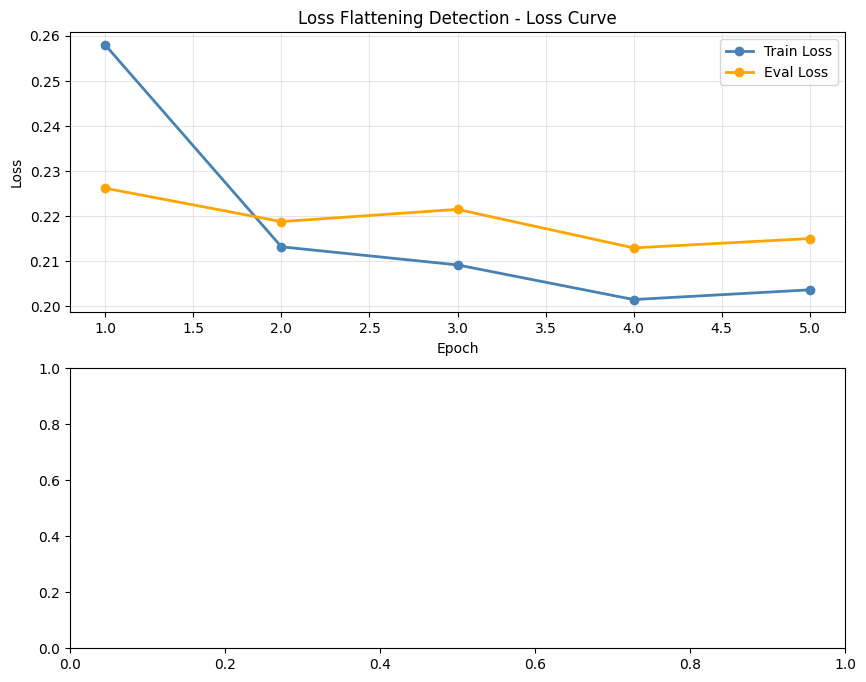


✗ Loss did not flatten within the training period (still improving)


In [25]:
plot_loss_flattening(train_losses, eval_losses, window_size=2)


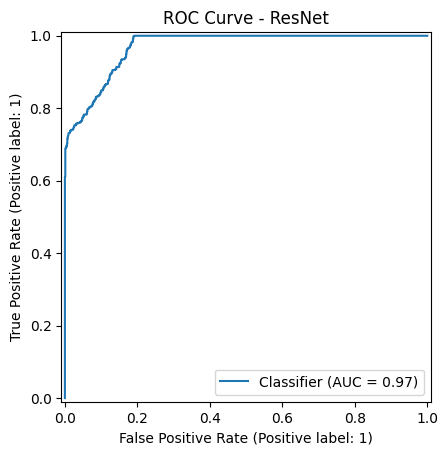

In [26]:

RocCurveDisplay.from_predictions(eval_labels, eval_preds)
plt.title("ROC Curve - ResNet")
plt.show()

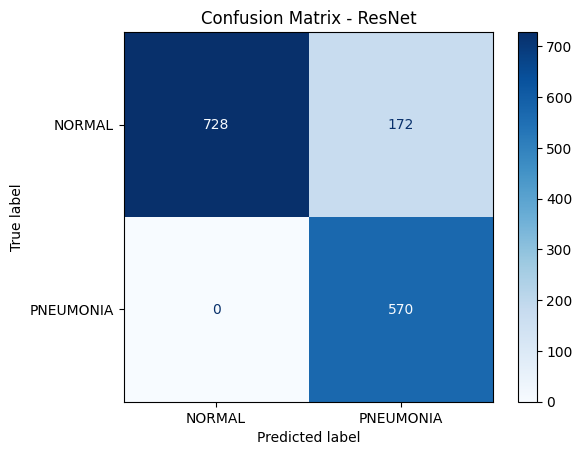

In [27]:

ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - ResNet")
plt.show()

In [28]:
import numpy as np
np.save("preds/resnet_test_preds.npy", test_preds.ravel())
np.save("preds/resnet_test_labels.npy", test_labels.ravel())

# ResNet Testing================

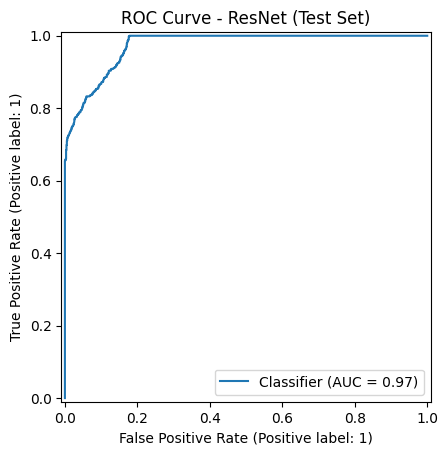

In [29]:
RocCurveDisplay.from_predictions(test_labels, test_preds)
plt.title("ROC Curve - ResNet (Test Set)")
plt.show()

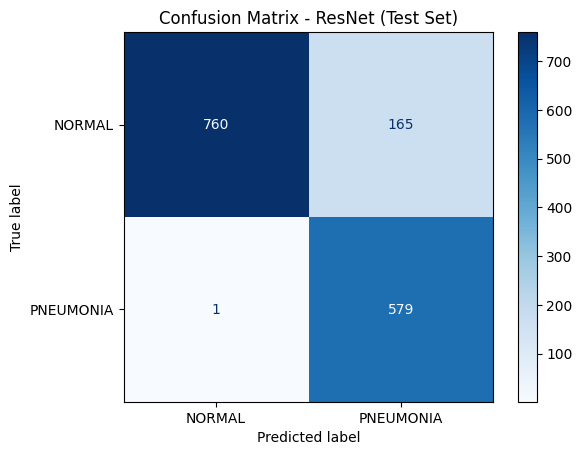

In [30]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - ResNet (Test Set)")
plt.show()